# Exploracion LSA sobre los textos usados por PAES (y PDT)

In [16]:
# !python -m spacy download es_core_news_sm

## Cargar Textos

In [99]:
documents = []
etiquetas = []
with open("paths.txt", "r", encoding="utf-8") as f:
    paths = f.readlines()
    for path in paths:
        path = path.strip()

        # asignamos un identificador unico a cada textos, para no tenga problema en graficar.
        # y ese identificador unico es su etiqueta
        etiqueta = path[9:path.rindex("\\")] + "-" + path[path.rindex("\\")+1:-4]
        etiquetas.append(etiqueta)

        ff = open(path, "r", encoding="utf-8")
        documents.append("".join(ff.readlines()).replace("\n", " ").strip().lower())

print(len(documents))

57


## Matriz A sin limpieza

In [100]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import matplotlib.pyplot as plt
import pandas as pd
from adjustText import adjust_text
import numpy as np

In [101]:
for style in ["seaborn-v0_8-whitegrid", "seaborn-whitegrid", "default"]:
    if style in plt.style.available or style == "default":
        plt.style.use(style)
        break

vectorizer_raw = CountVectorizer(
    lowercase=True,
    token_pattern=r"(?u)\b[^\W\d_]{3,}\b",
    min_df=1,
)

X_raw = vectorizer_raw.fit_transform(documents)
vocabulario_raw = vectorizer_raw.get_feature_names_out()
A_raw = X_raw.toarray().T

print("Forma de X_raw (documentos x terminos):", X_raw.shape)
print("Forma de A_raw (terminos x documentos):", A_raw.shape)
print("Primeros terminos del vocabulario:", vocabulario_raw[:30])

Forma de X_raw (documentos x terminos): (57, 9646)
Forma de A_raw (terminos x documentos): (9646, 57)
Primeros terminos del vocabulario: ['abajo' 'abandona' 'abandonado' 'abandonando' 'abandonar' 'abandonos'
 'abandonó' 'abanico' 'abarca' 'abarcar' 'abarcó' 'abarrotamos' 'abedules'
 'abetos' 'abierta' 'abierto' 'abiertos' 'abismos' 'abocan' 'abogacía'
 'abogado' 'abordadas' 'abordaje' 'abordar' 'abordó' 'abrazados' 'abre'
 'abriendo' 'abrieron' 'abrigan']


In [102]:
# funciones auxiliares
## fuente: documento de estudio en canvas

def tabla_resumen_distribucion(nombre, valores):
    return pd.DataFrame(
        [
            ["min", int(valores.min())],
            ["mediana", int(np.median(valores))],
            ["media", round(float(valores.mean()), 2)],
            ["max", int(valores.max())],
        ],
        columns=["estadistica", nombre],
    )

def resumen_vectorizacion(nombre, X, A, vocabulario):
    conteos_por_doc = np.asarray(X.sum(axis=1)).ravel()
    terminos_unicos_por_doc = np.asarray((X > 0).sum(axis=1)).ravel()
    total_celdas = X.shape[0] * X.shape[1]
    densidad = X.nnz / total_celdas

    tabla_corpus = pd.DataFrame(
        [
            ["numero_documentos", X.shape[0]],
            ["numero_terminos", X.shape[1]],
            ["forma_X_documentos_x_terminos", f"{X.shape[0]} x {X.shape[1]}"],
            ["forma_A_terminos_x_documentos", f"{A.shape[0]} x {A.shape[1]}"],
            ["entradas_no_cero", X.nnz],
            ["densidad", round(float(densidad), 4)],
            ["sparsity", round(float(1 - densidad), 4)],
        ],
        columns=["estadistica", nombre],
    )
    tabla_terminos_por_doc = tabla_resumen_distribucion(nombre, conteos_por_doc)
    tabla_terminos_unicos_por_doc = tabla_resumen_distribucion(nombre, terminos_unicos_por_doc)

    return (
        tabla_corpus,
        tabla_terminos_por_doc,
        tabla_terminos_unicos_por_doc,
        conteos_por_doc,
        terminos_unicos_por_doc,
    )

(
    tabla_corpus_raw,
    tabla_terminos_por_doc_raw,
    tabla_terminos_unicos_por_doc_raw,
    conteos_doc_raw,
    terminos_unicos_doc_raw,
) = resumen_vectorizacion(
    "corpus_sin_limpieza",
    X_raw,
    A_raw,
    vocabulario_raw,
)

display(tabla_corpus_raw)
display(tabla_terminos_por_doc_raw)
display(tabla_terminos_unicos_por_doc_raw)

,estadistica,corpus_sin_limpieza
0,numero_documentos,57
1,numero_terminos,9646
2,forma_X_documentos_x_terminos,57 x 9646
3,forma_A_terminos_x_documentos,9646 x 57
4,entradas_no_cero,22114
5,densidad,0.0402
6,sparsity,0.9598


,estadistica,corpus_sin_limpieza
0,min,0.00
1,mediana,718.00
2,media,666.12
3,max,1004.00


,estadistica,corpus_sin_limpieza
0,min,0.00
1,mediana,413.00
2,media,387.96
3,max,597.00


## limpirza, lemalizar y eliminacion de stopword

In [103]:
import spacy

In [107]:
try:
    nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])
except OSError as exc:
    raise OSError(
        "No encontre el modelo es_core_news_sm. Ejecuta la celda de instalacion: "
        "!python -m spacy download es_core_news_sm"
    ) from exc

# https://github.com/Alir3z4/stop-words/blob/master/spanish.txt
with open("./stopword.txt", encoding="utf-8") as f:
    stop_words = [l.strip() for l in f.readlines()]

stop_words_raw = sorted(set(stop_words))


def lematizar_lista(palabras):
    lemas = set()
    for palabra in palabras:
        doc = nlp(palabra)
        for token in doc:
            lema = token.lemma_.lower().strip()
            if lema:
                lemas.add(lema)
    return lemas


# Filtramos dos veces: primero en la forma original del token y luego en su lema.
stop_words_lem = lematizar_lista(stop_words_raw)
stop_words_total = sorted(set(stop_words_raw) | stop_words_lem)


def lematizar_texto(texto):
    doc = nlp(texto)
    lemas = []
    for token in doc:
        texto_token = token.text.lower().strip()
        lema = token.lemma_.lower().strip()
        if not texto_token or not lema or token.is_space:
            continue
        if len(texto_token) < 3 or len(lema) < 3:
            continue
        if texto_token in stop_words_total or lema in stop_words_total:
            continue
        lemas.append(lema)
    return " ".join(lemas)

documentos_lem = [lematizar_texto(texto) for texto in documents]


print("Ejemplo original:")
print(documents[0][:300])
print("\nEjemplo lematizado y filtrado:")
print(documentos_lem[0][:300])
print("\nStopwords finales:", stop_words_total[:40])

Ejemplo original:
el lenguaje que nos identifica  1. ¿cuándo comenzamos a conformar nuestra identidad? 2. durante el primer año de nuestra vida, empezamos a conformar nuestra identidad como integrantes de una familia inserta en una comunidad de cultura y lenguaje. desde ese momento estamos aprendiendo a ser nosotros 

Ejemplo lematizado y filtrado:
lenguaje identificar cuándo comenzar conformar identidad año vida empezar conformar identidad integrante familia inserto comunidad cultura lenguaje aprender tarea continuar vida chico percibimos mensaje sociedad valorar desvalora familia comunidad reforzar debilitar idea dinámica influencia hablar i

Stopwords finales: ["'", 'a', 'acerca', 'actualmente', 'adelante', 'además', 'adonde', 'afirmar', 'afirmó', 'agregar', 'agregó', 'ahora', 'ahí', 'al', 'algo', 'alguna', 'algunas', 'alguno', 'algunos', 'algún', 'allende', 'allendir', 'alrededor', 'ambos', 'ampleamos', 'amplear', 'amén', 'ante', 'anterior', 'antes', 'apenas', 'aproximadamente', 'a

## Construir vocabulario y matriz A

In [110]:
# usamos TF-IDF
vectorizer_final = TfidfVectorizer(
    lowercase=True,
    token_pattern=r"(?u)\b[^\W\d_]{3,}\b",
    stop_words=stop_words_total,
    min_df=2,
    max_df=0.8,
    # no usamos bigramas
    ngram_range=(1, 1),
)

# usamos el transpuesta para seguir el convención de la clase
A_final = vectorizer_final.fit_transform(documentos_lem).toarray().T
vocabulario_final = vectorizer_final.get_feature_names_out()

vectorizer_final_counts = CountVectorizer(vocabulary=vocabulario_final)
X_final_counts = vectorizer_final_counts.transform(documentos_lem)
frecuencias_final = np.asarray(X_final_counts.sum(axis=0)).ravel()

print("Cantidad de vocabulario:", len(vocabulario_final))
print("Primeros terminos del vocabulario final:", vocabulario_final[:30])

print("Forma de A_final (terminos x documentos):", A_final.shape)

Cantidad de vocabulario: 2445
Primeros terminos del vocabulario final: ['abajo' 'abandonar' 'abarcar' 'abierto' 'abordar' 'abrigo' 'abril'
 'abrir' 'absoluto' 'absorber' 'abstracción' 'abstracto' 'abuelo'
 'acabado' 'acabar' 'academia' 'académico' 'acalambrar' 'acariciar'
 'acaso' 'acceder' 'acceso' 'accidente' 'accionar' 'acción' 'aceite'
 'acelerado' 'aceptar' 'acercar' 'acoger']
Forma de A_final (terminos x documentos): (2445, 57)


In [111]:
# guardar vocabulario
f = open("./vocabulario_final.txt", "w+", encoding="utf-8")
f.write("\n".join(vocabulario_final))
f.close()

In [112]:
# funciones axuliares
## fuente: documento de estudio en canvas
(
    tabla_corpus_final,
    tabla_terminos_por_doc_final,
    tabla_terminos_unicos_por_doc_final,
    conteos_doc_final,
    terminos_unicos_doc_final,
) = resumen_vectorizacion(
    "despues_preprocesamiento",
    X_final_counts,
    A_final,
    vocabulario_final,
)

tabla_corpus_comparacion = tabla_corpus_raw.merge(tabla_corpus_final, on="estadistica")
tabla_terminos_por_doc = tabla_terminos_por_doc_raw.merge(tabla_terminos_por_doc_final, on="estadistica")
tabla_terminos_unicos_por_doc = tabla_terminos_unicos_por_doc_raw.merge(tabla_terminos_unicos_por_doc_final, on="estadistica")


def valor_numerico(tabla, estadistica, columna):
    return float(tabla.loc[tabla["estadistica"] == estadistica, columna].iloc[0])


def fila_cambio(tabla, estadistica, nombre):
    antes = valor_numerico(tabla, estadistica, "corpus_sin_limpieza")
    despues = valor_numerico(tabla, estadistica, "despues_preprocesamiento")
    cambio_pct = 100 * (despues - antes) / antes if antes != 0 else np.nan
    return [nombre, antes, despues, round(cambio_pct, 2)]


filas_cambio = [
    fila_cambio(tabla_corpus_comparacion, "numero_terminos", "numero_terminos"),
    fila_cambio(tabla_corpus_comparacion, "entradas_no_cero", "entradas_no_cero"),
    fila_cambio(tabla_corpus_comparacion, "densidad", "densidad"),
    fila_cambio(tabla_corpus_comparacion, "sparsity", "sparsity"),
    fila_cambio(tabla_terminos_por_doc, "media", "media_terminos_por_doc"),
    fila_cambio(tabla_terminos_unicos_por_doc, "media", "media_terminos_unicos_por_doc"),
]

tabla_cambio = pd.DataFrame(
    filas_cambio,
    columns=["estadistica", "antes", "despues", "cambio_%"],
)


display(tabla_corpus_comparacion)
display(tabla_cambio)

,estadistica,corpus_sin_limpieza,despues_preprocesamiento
0,numero_documentos,57,57
1,numero_terminos,9646,2445
2,forma_X_documentos_x_terminos,57 x 9646,57 x 2445
3,forma_A_terminos_x_documentos,9646 x 57,2445 x 57
4,entradas_no_cero,22114,10890
5,densidad,0.0402,0.0781
6,sparsity,0.9598,0.9219


,estadistica,antes,despues,cambio_%
0,numero_terminos,9646.0000,2445.0000,-74.65
1,entradas_no_cero,22114.0000,10890.0000,-50.76
2,densidad,0.0402,0.0781,94.28
3,sparsity,0.9598,0.9219,-3.95
4,media_terminos_por_doc,666.1200,301.3200,-54.76
5,media_terminos_unicos_por_doc,387.9600,191.0500,-50.76


# SVD

In [113]:
U_final, s_final, VT_final = np.linalg.svd(A_final, full_matrices=False)

print("Primeros valores singulares con stopwords + Lematizacion + TF-IDF:")
print(np.round(s_final[:10], 3))

Primeros valores singulares con stopwords + Lematizacion + TF-IDF:
[2.033 1.305 1.257 1.236 1.201 1.16  1.139 1.12  1.101 1.095]


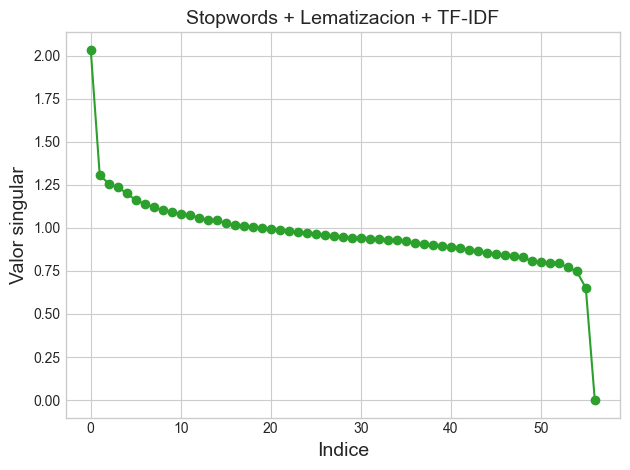

In [114]:
plt.plot(s_final, marker="o", color="tab:green")
plt.title("Stopwords + Lematizacion + TF-IDF", fontsize=14)
plt.xlabel("Indice", fontsize=14)
plt.ylabel("Valor singular", fontsize=14)

plt.tight_layout()
plt.show()

## Planos 2D

In [116]:
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm

# funciones auxiliar
## fuente: documento de estudio en canvas
def coordenadas_documentos(s, VT, componentes=(1, 2)):
    indices = [componente - 1 for componente in componentes]
    return np.diag(s[indices]) @ VT[indices, :]

def coordenadas_terminos(U, s, componentes=(1, 2)):
    indices = [componente - 1 for componente in componentes]
    return U[:, indices] @ np.diag(s[indices])

def etiqueta_corta_documento(etiqueta):
    return Path(etiqueta).stem

def grupo_documento(etiqueta):
    # usando el año
    return etiqueta[:4]

def colores_documentos(etiquetas_docs):
    cmap_anual = plt.get_cmap("tab10")
    colores_anual = {f"202{i+2}": cmap_anual(0.22 + 0.68 * (i - 1) / 7) for i in range(1, 5)}
    mapa_colores = {**colores_anual, "otros": "tab:gray"}
    grupos = [grupo_documento(etiqueta) for etiqueta in etiquetas_docs]
    colores = [mapa_colores.get(grupo, "tab:gray") for grupo in grupos]
    return grupos, colores, mapa_colores

def graficar_documentos_y_terminos(
    coords_docs,
    coords_terms,
    etiquetas_docs,
    vocabulario,
    frecuencias_terminos,
    titulo,
    componentes=(1, 2),
    n_terms=40,
):
    normas_terms = np.linalg.norm(coords_terms, axis=1)
    indices_terms = np.argsort(normas_terms)[::-1][:n_terms]
    term_freq = np.asarray(frecuencias_terminos).ravel()
    term_freq_plot = np.maximum(term_freq[indices_terms], 1)

    grupos_docs, colores_docs, mapa_colores_docs = colores_documentos(etiquetas_docs)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

    axes[0].scatter(
        coords_docs[0, :],
        coords_docs[1, :],
        s=95,
        c=colores_docs,
        edgecolor="white",
        linewidth=0.7,
    )
    texts_docs = []
    for i, etiqueta in enumerate(etiquetas_docs):
        texts_docs.append(
            axes[0].text(
                coords_docs[0, i],
                coords_docs[1, i],
                etiqueta_corta_documento(etiqueta),
                fontsize=11,
            )
        )
    axes[0].grid(False)
    adjust_text(
        texts_docs,
        ax=axes[0],
        expand_text=(1.25, 1.45),
        expand_points=(1.25, 1.45),
        force_text=(0.5, 0.7),
        force_points=(0.25, 0.35),
        arrowprops=dict(arrowstyle="-", color="0.45", lw=0.7),
    )
    axes[0].axhline(0, color="gray", linewidth=1.0)
    axes[0].axvline(0, color="gray", linewidth=1.0)
    axes[0].set_title("Documentos", fontsize=18)
    axes[0].set_xlabel(f"Componente {componentes[0]}", fontsize=14)
    axes[0].set_ylabel(f"Componente {componentes[1]}", fontsize=14)
    axes[0].tick_params(axis="both", labelsize=12)

    grupos_presentes = []
    for grupo in grupos_docs:
        if grupo not in grupos_presentes:
            grupos_presentes.append(grupo)
    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label=grupo,
            markerfacecolor=mapa_colores_docs.get(grupo, "tab:brown"),
            markeredgecolor="white",
            markersize=10,
        )
        for grupo in grupos_presentes
    ]
    axes[0].legend(handles=handles, fontsize=10, loc="best", frameon=True, ncol=2)

    normalizador = LogNorm(vmin=max(term_freq_plot.min(), 1), vmax=max(term_freq_plot.max(), 1))
    scatter_terms = axes[1].scatter(
        coords_terms[indices_terms, 0],
        coords_terms[indices_terms, 1],
        s=75,
        c=term_freq_plot,
        cmap="viridis",
        norm=normalizador,
        edgecolor="white",
        linewidth=0.5,
    )
    texts_terms = []
    axes[1].grid(False)
    for i in indices_terms:
        texts_terms.append(axes[1].text(coords_terms[i, 0], coords_terms[i, 1], vocabulario[i], fontsize=10))
    adjust_text(
        texts_terms,
        ax=axes[1],
        expand_text=(1.2, 1.4),
        expand_points=(1.2, 1.4),
        force_text=(0.45, 0.65),
        force_points=(0.25, 0.35),
        arrowprops=dict(arrowstyle="-", color="0.45", lw=0.7),
    )
    axes[1].axhline(0, color="gray", linewidth=1.0)
    axes[1].axvline(0, color="gray", linewidth=1.0)
    axes[1].set_title("Terminos", fontsize=18)
    axes[1].set_xlabel(f"Componente {componentes[0]}", fontsize=14)
    axes[1].set_ylabel(f"Componente {componentes[1]}", fontsize=14)
    axes[1].tick_params(axis="both", labelsize=12)
    cax = axes[1].inset_axes([1.04, 0, 0.04, 1])
    cax.grid(False)
    cbar = fig.colorbar(scatter_terms, cax=cax)
    cbar.ax.grid(False)
    cbar.set_label("Frecuencia en el corpus", fontsize=12)
    cbar.ax.tick_params(labelsize=11)

    fig.suptitle(titulo, fontsize=20)
    plt.tight_layout()
    plt.show()

In [117]:
# funcion auxiliar para visualizar plano 2d
def visualizar_ab(componente_a, componente_b):
    docs_ab_final = coordenadas_documentos(s_final, VT_final, componentes=(componente_a, componente_b))
    terms_ab_final = coordenadas_terminos(U_final, s_final, componentes=(componente_a, componente_b))

    graficar_documentos_y_terminos(
        docs_ab_final,
        terms_ab_final,
        etiquetas,
        vocabulario_final,
        frecuencias_final,
        f"LSA con stopwords + Lematizacion + TF-IDF: componentes {componente_a} vs {componente_b}",
        componentes=(componente_a, componente_b),
        n_terms=45,
    )

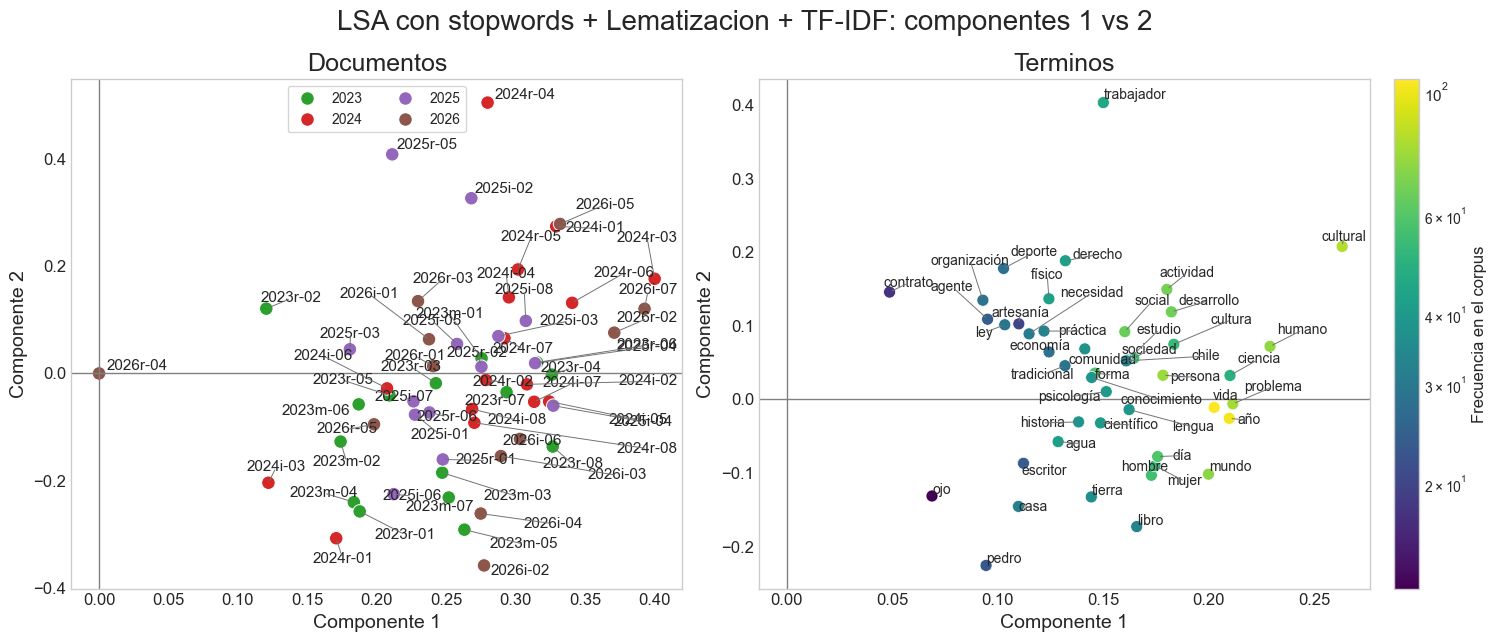

In [118]:
# componente 1 y 2
visualizar_ab(1, 2)

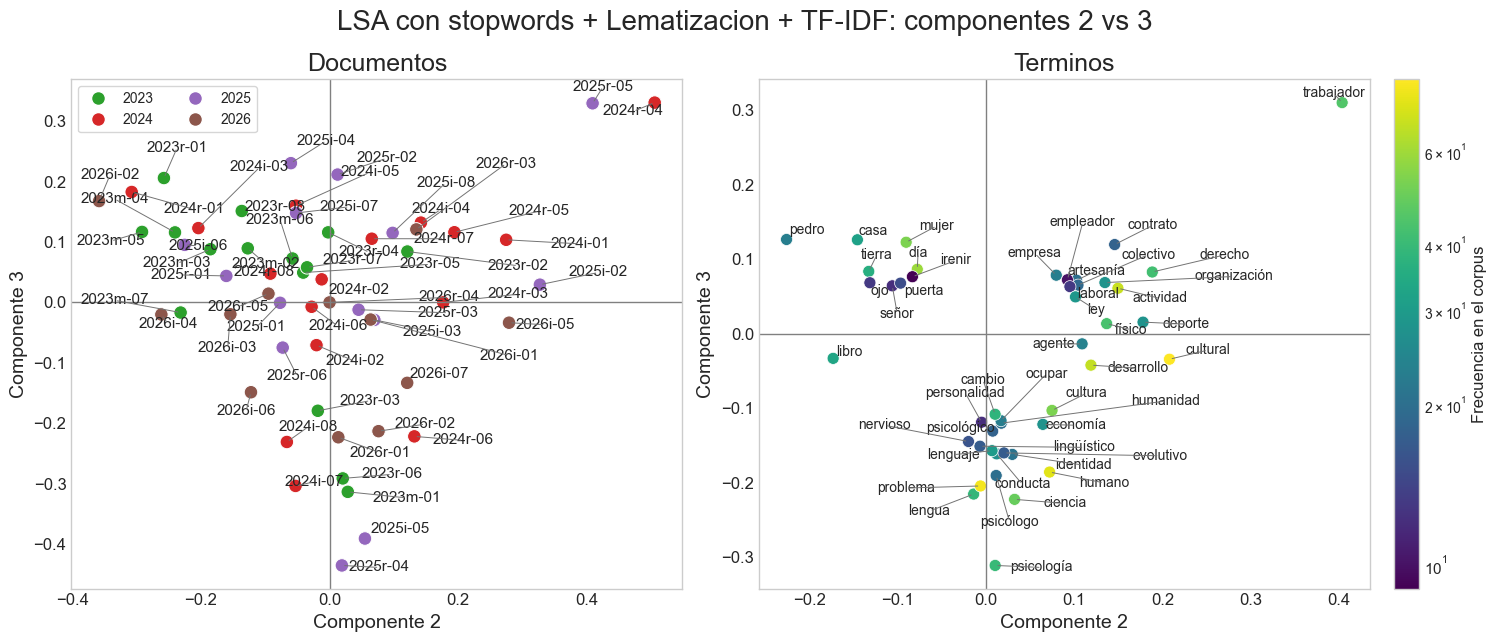

In [119]:
# componente 2 y 3
visualizar_ab(2, 3)

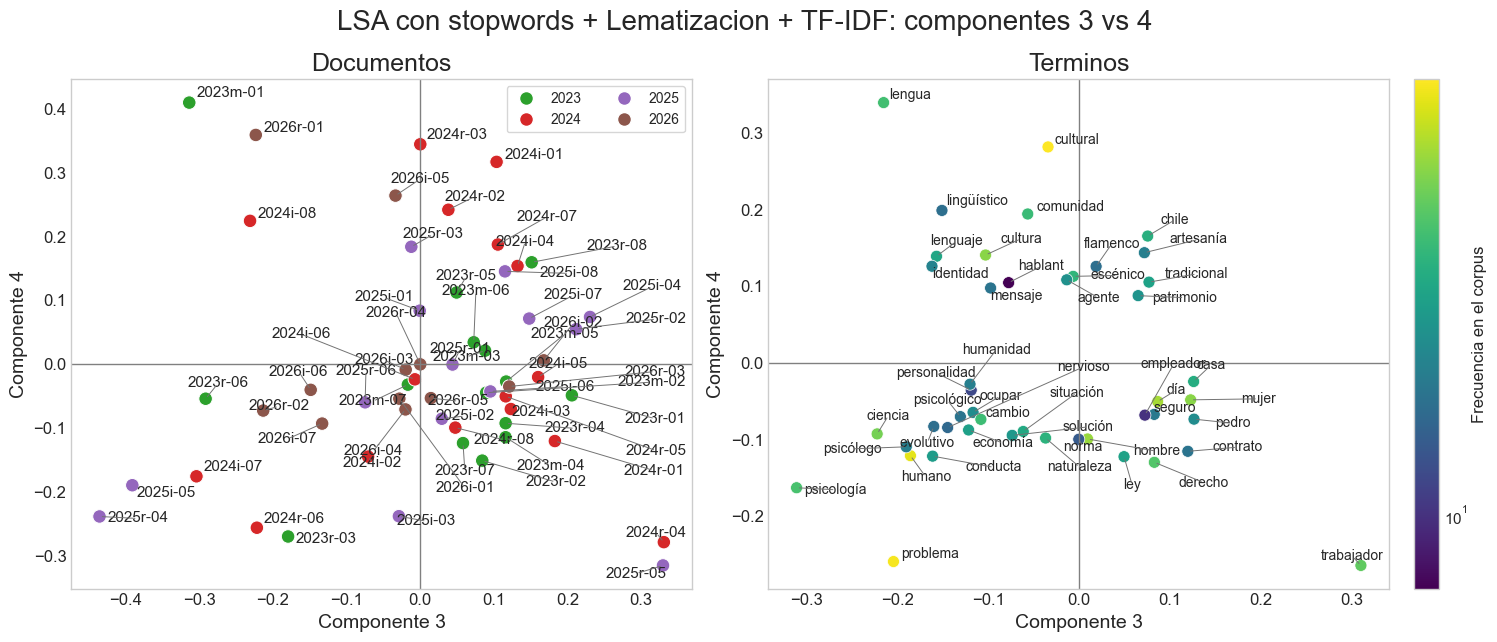

In [120]:
# componente 3 y 4
visualizar_ab(3, 4)